# Train YOLO11n — Motorcycle Detector

## Section 1: Cài đặt môi trường & Cấu hình

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kronomy/helmet-dataset-by-osf-lite")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite


In [2]:
# ============================================================================
# CÀI ĐẶT: Upgrade Ultralytics để có YOLO11
# ============================================================================
import subprocess, sys

# YOLO11 yêu cầu ultralytics >= 8.3.0
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--upgrade', 'ultralytics>=8.3.0', '-q'],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else '')

# Verify version
import ultralytics
print(f'✓ Ultralytics version: {ultralytics.__version__}')

# Kiểm tra GPU
import torch
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
print(f'✓ GPU: {gpu_name} | VRAM: {gpu_mem:.1f} GB')
print(f'✓ CUDA available: {torch.cuda.is_available()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Ultralytics version: 8.4.33
✓ GPU: Tesla T4 | VRAM: 15.6 GB
✓ CUDA available: True


In [ ]:
import os
import shutil
import json
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from pathlib import Path
from datetime import datetime

# ============================================================================
# ⚙️  CẤU HÌNH — Chỉnh sửa tại đây nếu cần
# ============================================================================

# --- Đường dẫn INPUT  ---
# Thay tên dataset nếu khác
YOLO_DATASET_INPUT = '/kaggle/working/yolo_dataset'

# --- Đường dẫn OUTPUT ---
OUTPUT_BASE   = '/kaggle/working'
RUNS_DIR      = os.path.join(OUTPUT_BASE, 'runs', 'helmet_yolo_v2')
FINAL_WEIGHTS = os.path.join(OUTPUT_BASE, 'yolo_best_v2.pt')
SUMMARY_PATH  = os.path.join(OUTPUT_BASE, 'step2_v2_train_summary.json')
DATA_YAML     = os.path.join(YOLO_DATASET_INPUT, 'data.yaml')  

# --- Model & Hyperparameters ---
MODEL_NAME  = 'yolo11n.pt'   
IMG_SIZE    = 640           
EPOCHS      = 50             
BATCH_SIZE  = 16              
PATIENCE    = 12             
WARMUP_EP   = 5             
SEED        = 42

# --- Augmentation flags ---
# (Phần lớn do Ultralytics handle tự động, chỉ tune các param quan trọng)
MOSAIC      = 1.0   # Mosaic augmentation probability
COPY_PASTE  = 0.1   # Copy-paste augmentation (tốt cho dense scenes như traffic)
MIXUP       = 0.05  # MixUp augmentation probability
DEGREES     = 5.0   # Rotation degrees (nhẹ — xe trên đường không xoay nhiều)
TRANSLATE   = 0.1   # Translation
SCALE       = 0.5   # Scale augmentation
FLIPLR      = 0.5   # Horizontal flip (OK cho detection — không như classifier)
HSV_H       = 0.015 # Hue
HSV_S       = 0.7   # Saturation
HSV_V       = 0.4   # Value/brightness
LABEL_SMOOTHING = 0.1  # Label smoothing → tránh overconfident

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)

print('=' * 70)
print('⚙️  CẤU HÌNH TRAINING')
print('=' * 70)
print(f'  Model        : {MODEL_NAME}')
print(f'  imgsz        : {IMG_SIZE} (so với 640 cũ → +{IMG_SIZE/640:.1f}x detail)')
print(f'  Epochs       : {EPOCHS} (max, có early stopping patience={PATIENCE})')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Data yaml    : {DATA_YAML}')
print(f'  Runs dir     : {RUNS_DIR}')
print('=' * 70)


⚙️  CẤU HÌNH TRAINING
  Model        : yolo11n.pt
  imgsz        : 640 (so với 640 cũ → +1.0x detail)
  Epochs       : 50 (max, có early stopping patience=12)
  Batch size   : 16
  Data yaml    : /kaggle/working/yolo_dataset/data.yaml
  Runs dir     : /kaggle/working/runs/helmet_yolo_v2


## Section 1B: Prepare YOLO Dataset 
Tải dataset từ osf-lite và chuyển đổi sang format YOLO.

## Section 1: Import Required Libraries and Setup Paths

In [4]:
import os
import pandas as pd
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
from shutil import copyfile
import json
from collections import defaultdict

# Install required packages if needed
# !pip install pandas opencv-python tqdm

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [ ]:
# ============================================================================
# CONFIGURATION: Define paths and constants
# ============================================================================

# Kaggle Dataset Paths (FIXED - include /datasets/kronomy/)
ROOT_DIR = '/kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite/helmet-dataset'

# Output Directories
OUTPUT_BASE = '/kaggle/working'
YOLO_DIR = os.path.join(OUTPUT_BASE, 'yolo_dataset')  # For YOLO detector training
CROPS_DIR = os.path.join(OUTPUT_BASE, 'cropped_motorcycles')  # For EfficientNetV2 training

# Image Resolution (from dataset specification)
IMAGE_HEIGHT, IMAGE_WIDTH = 1080, 1920

# Create output directories
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DIR, split, 'labels'), exist_ok=True)

print(f"✓ Paths configured:")
print(f"  - Root: {ROOT_DIR}")
print(f"  - YOLO output: {YOLO_DIR}")
print(f"  - Crops output: {CROPS_DIR}")
print(f"  - Image resolution: {IMAGE_WIDTH}x{IMAGE_HEIGHT}")

✓ Paths configured:
  - Root: /kaggle/input/datasets/kronomy/helmet-dataset-by-osf-lite/helmet-dataset
  - YOLO output: /kaggle/working/yolo_dataset
  - Crops output: /kaggle/working/cropped_motorcycles
  - Image resolution: 1920x1080


## Section 2: Explore Dataset Structure

In [6]:
# ============================================================================
# STEP 1: Explore dataset structure
# ============================================================================

print("=" * 80)
print("EXPLORING DATASET STRUCTURE")
print("=" * 80)

# List all parts (image folders)
images_base = os.path.join(ROOT_DIR, 'images')
parts = sorted([d for d in os.listdir(images_base) if d.startswith('part_')])
print(f"\n✓ Found {len(parts)} parts: {parts}")

# List all annotation files
annotation_base = os.path.join(ROOT_DIR, 'annotation/annotation')
annotation_files = [f for f in os.listdir(annotation_base) if f.endswith('.csv')]
print(f"✓ Found {len(annotation_files)} annotation files")
print(f"  Sample annotation files: {annotation_files[:5]}")

# Check data_split.csv
split_csv = os.path.join(ROOT_DIR, 'data_split.csv')
split_df = pd.read_csv(split_csv)
print(f"\n✓ Data split info:")
print(f"  - Total clips: {len(split_df)}")
print(f"  - Train: {len(split_df[split_df['Set'] == 'training'])}")
print(f"  - Val: {len(split_df[split_df['Set'] == 'validation'])}")
print(f"  - Test: {len(split_df[split_df['Set'] == 'test'])}")

# Display sample records
print(f"\n✓ Sample data_split.csv records:")
print(split_df.head())

# Inspect a sample annotation file
sample_clip = annotation_files[0].replace('.csv', '')
sample_ann_path = os.path.join(annotation_base, f"{sample_clip}.csv")
sample_ann_df = pd.read_csv(sample_ann_path)
print(f"\n✓ Sample annotation file ({sample_clip}.csv) structure:")
print(f"  - Shape: {sample_ann_df.shape}")
print(f"  - Columns: {list(sample_ann_df.columns)}")
print(f"\n  Sample rows:")
print(sample_ann_df.head(10))

# Check frame images for a sample clip
for part in parts:
    clip_dir = os.path.join(images_base, part, sample_clip)
    if os.path.exists(clip_dir):
        frames = [f for f in os.listdir(clip_dir) if f.endswith('.jpg')]
        print(f"\n✓ Sample clip ({sample_clip}) in {part}:")
        print(f"  - Frames found: {len(frames)}")
        print(f"  - Sample frames: {sorted(frames)[:5]}")
        break


EXPLORING DATASET STRUCTURE

✓ Found 2 parts: ['part_1', 'part_2']
✓ Found 910 annotation files
  Sample annotation files: ['Pakokku_urban_54.csv', 'Mandalay_2_133.csv', 'Mandalay_2_188.csv', 'Mandalay_2_63.csv', 'Mandalay_1_134.csv']

✓ Data split info:
  - Total clips: 910
  - Train: 636
  - Val: 92
  - Test: 182

✓ Sample data_split.csv records:
          video_id         Set
0   Bago_highway_1  validation
1  Bago_highway_10        test
2  Bago_highway_11    training
3  Bago_highway_12    training
4  Bago_highway_13    training

✓ Sample annotation file (Pakokku_urban_54.csv) structure:
  - Shape: (304, 7)
  - Columns: ['track_id', 'frame_id', 'x', 'y', 'w', 'h', 'label']

  Sample rows:
     track_id  frame_id     x    y   w    h            label
0  _9ij3ker8j         1  1581  328  55  102  DHelmetP1Helmet
1  _9ij3ker8j         2  1570  329  56  104  DHelmetP1Helmet
2  _9ij3ker8j         3  1559  331  57  104  DHelmetP1Helmet
3  _9ij3ker8j         4  1548  332  58  105  DHelmetP1He

## Section 3: Load and Parse Annotations

In [7]:
def parse_all_riders_from_label(label_str):
    """
    Extract ALL riders from combined label string.
    
    Format: DHelmetP1NoHelmet = Driver(WithHelmet) + Passenger1(NoHelmet)
    
    Args:
        label_str: Combined label string from annotation
    
    Returns:
        List of tuples [(rider_pos, helmet_status), ...]
        e.g., [('Driver', 'WithHelmet'), ('Passenger1', 'NoHelmet')]
    """
    import re
    label_str = str(label_str).strip()
    
    riders_map = {
        'D': 'Driver', 
        'P0': 'Child', 
        'P1': 'Passenger1', 
        'P2': 'Passenger2', 
        'P3': 'Passenger3'
    }
    riders = []
    
    # Match patterns: D/P0/P1/P2/P3 followed by Helmet or NoHelmet
    pattern = r'(D|P[0-3])(Helmet|NoHelmet)'
    matches = re.findall(pattern, label_str)
    
    for rider_code, helmet_code in matches:
        rider_pos = riders_map.get(rider_code, 'Unknown')
        helmet_status = "WithHelmet" if helmet_code == "Helmet" else "NoHelmet"
        riders.append((rider_pos, helmet_status))
    
    return riders

print("✓ Utility function defined: parse_all_riders_from_label()")

def get_yolo_class(rider_position, helmet_status):
    """
    Convert rider position and helmet status to YOLO class ID (for motorcycle detection).
    For motorcycle detection, we use: 0 = compliant, 1 = violation (any person without helmet)
    
    Args:
        rider_position: str
        helmet_status: str
    
    Returns:
        int: YOLO class ID (0 or 1)
    """
    # 0: compliant (all riders have helmets), 1: violation (any rider without helmet)
    if helmet_status == "NoHelmet":
        return 1
    else:
        return 0

def normalize_bbox(x, y, w, h, img_width=IMAGE_WIDTH, img_height=IMAGE_HEIGHT):
    """
    Convert bounding box from absolute coordinates to YOLO normalized format.
    
    Args:
        x, y, w, h: Absolute pixel coordinates (x, y top-left, w, h width/height)
        img_width, img_height: Image dimensions
    
    Returns:
        tuple: (center_x_norm, center_y_norm, width_norm, height_norm) normalized to [0, 1]
    """
    center_x = x + w / 2
    center_y = y + h / 2
    
    center_x_norm = center_x / img_width
    center_y_norm = center_y / img_height
    width_norm = w / img_width
    height_norm = h / img_height
    
    return center_x_norm, center_y_norm, width_norm, height_norm

print("✓ Utility functions defined: parse_label_string, get_yolo_class, normalize_bbox")


✓ Utility function defined: parse_all_riders_from_label()
✓ Utility functions defined: parse_label_string, get_yolo_class, normalize_bbox


## Section 4: Convert Annotations to YOLO Format

In [8]:
print("=" * 80)
print("CONVERTING ANNOTATIONS TO YOLO FORMAT")
print("=" * 80)

# Load data splits
split_df = pd.read_csv(os.path.join(ROOT_DIR, 'data_split.csv'))

# Map splits
split_map = {
    'training': 'train',
    'validation': 'val',
    'test': 'test'
}

# Statistics
stats = {
    'processed_clips': 0,
    'skipped_clips': 0,
    'processed_frames': 0,
    'total_objects': 0,
    'splits': defaultdict(lambda: {'images': 0, 'objects': 0})
}

# List all parts
images_base = os.path.join(ROOT_DIR, 'images')
annotation_base = os.path.join(ROOT_DIR, 'annotation/annotation')
parts = sorted([d for d in os.listdir(images_base) if d.startswith('part_')])

# Process each clip
pbar = tqdm(split_df.iterrows(), total=len(split_df), desc="Processing clips")

for idx, row in pbar:
    clip_name = row['video_id']
    dataset_split = split_map.get(row['Set'], 'unknown')
    
    # Skip unknown splits
    if dataset_split == 'unknown':
        stats['skipped_clips'] += 1
        continue
    
    # Check if annotation exists
    ann_path = os.path.join(annotation_base, f"{clip_name}.csv")
    if not os.path.exists(ann_path):
        stats['skipped_clips'] += 1
        continue
    
    # Load annotations
    ann_df = pd.read_csv(ann_path)
    
    # Find image directory for this clip
    clip_img_dir = None
    for part in parts:
        potential_dir = os.path.join(images_base, part, clip_name)
        if os.path.exists(potential_dir):
            clip_img_dir = potential_dir
            break
    
    if not clip_img_dir:
        stats['skipped_clips'] += 1
        continue
    
    stats['processed_clips'] += 1
    
    # Process each frame
    for frame_id in range(1, 101):  # 100 frames per clip
        frame_filename = f"{frame_id}.jpg"
        img_path = os.path.join(clip_img_dir, frame_filename)
        
        if not os.path.exists(img_path):
            continue
        
        stats['processed_frames'] += 1
        stats['splits'][dataset_split]['images'] += 1
        
        # Create output paths
        out_img_name = f"{clip_name}_{frame_filename}"
        out_img_path = os.path.join(YOLO_DIR, dataset_split, 'images', out_img_name)
        
        # Copy or symlink image
        if not os.path.exists(out_img_path):
            try:
                os.symlink(img_path, out_img_path)
            except:
                copyfile(img_path, out_img_path)
        
        # Create YOLO label file
        label_filename = f"{clip_name}_{frame_id}.txt"
        label_path = os.path.join(YOLO_DIR, dataset_split, 'labels', label_filename)
        
        with open(label_path, 'w') as f:
            # Get all detections for this frame
            frame_ann = ann_df[ann_df['frame_id'] == frame_id]
            
            for _, ann_row in frame_ann.iterrows():
                x = ann_row['x']
                y = ann_row['y']
                w = ann_row['w']
                h = ann_row['h']
                label_str = ann_row.get('label', '')
                track_id = ann_row.get('track_id', -1)
                
                # Get YOLO class (0=compliant, 1=violation)
                riders = parse_all_riders_from_label(label_str)
                yolo_class = 1 if any(status == "NoHelmet" for _, status in riders) else 0
                
                # Normalize bbox
                center_x_norm, center_y_norm, width_norm, height_norm = normalize_bbox(x, y, w, h)
                
                # Write YOLO format
                f.write(f"{yolo_class} {center_x_norm:.6f} {center_y_norm:.6f} {width_norm:.6f} {height_norm:.6f}\n")
                
                stats['total_objects'] += 1
                stats['splits'][dataset_split]['objects'] += 1

print("\n✓ YOLO format conversion completed!")
print(f"\nStatistics:")
print(f"  - Processed clips: {stats['processed_clips']}")
print(f"  - Skipped clips: {stats['skipped_clips']}")
print(f"  - Processed frames: {stats['processed_frames']}")
print(f"  - Total objects: {stats['total_objects']}")
print(f"\n  Split breakdown:")
for split_name, data in stats['splits'].items():
    print(f"    {split_name}: {data['images']} images, {data['objects']} objects")


CONVERTING ANNOTATIONS TO YOLO FORMAT


Processing clips: 100%|██████████| 910/910 [02:01<00:00,  7.49it/s]


✓ YOLO format conversion completed!

Statistics:
  - Processed clips: 287
  - Skipped clips: 623
  - Processed frames: 26117
  - Total objects: 73530

  Split breakdown:
    val: 3003 images, 8553 objects
    test: 5096 images, 13710 objects
    train: 18018 images, 51267 objects


## Section 2: Kiểm tra Dataset từ Step 1

In [9]:
# ============================================================================
# TẠO FILE data.yaml CHO YOLO NẾU BỊ THIẾU
# ============================================================================
import yaml
import os

YOLO_DIR = '/kaggle/working/yolo_dataset'
data_yaml_path = os.path.join(YOLO_DIR, 'data.yaml')

data_cfg = {
    'path': YOLO_DIR,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 2,
    'names': {0: 'compliant', 1: 'violation'}
}

# Đảm bảo thư mục tồn tại trước khi ghi
os.makedirs(YOLO_DIR, exist_ok=True)

with open(data_yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Created {data_yaml_path}")


✓ Created /kaggle/working/yolo_dataset/data.yaml


In [10]:
# ============================================================================
# VERIFY: Kiểm tra dataset đầu vào từ Step 1
# ============================================================================

def verify_yolo_dataset(dataset_dir: str) -> dict:
    """
    Kiểm tra tính toàn vẹn của YOLO dataset từ Step 1.
    Trả về thống kê chi tiết.
    """
    stats = {}
    
    print('=' * 70)
    print('🔍 KIỂM TRA YOLO DATASET (output của Step 1)')
    print('=' * 70)
    
    # Kiểm tra data.yaml
    yaml_path = os.path.join(dataset_dir, 'data.yaml')
    if not os.path.exists(yaml_path):
        raise FileNotFoundError(f'❌ Không tìm thấy data.yaml tại: {yaml_path}\n'
                                f'   Hãy đảm bảo đã add dataset Step 1 vào Kaggle input!')
    
    with open(yaml_path) as f:
        data_cfg = yaml.safe_load(f)
    print(f'✓ data.yaml: {yaml_path}')
    print(f'  Classes ({data_cfg.get("nc")}): {data_cfg.get("names")}')
    stats['classes'] = data_cfg.get('names')
    stats['nc']      = data_cfg.get('nc')
    
    # Kiểm tra từng split
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(dataset_dir, split, 'images')
        lbl_dir = os.path.join(dataset_dir, split, 'labels')
        
        if not os.path.exists(img_dir):
            print(f'  ⚠️  {split}/images không tồn tại — bỏ qua')
            continue
        
        imgs  = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))]
        lbls  = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')] if os.path.exists(lbl_dir) else []
        
        # Đếm objects per class
        cls_counts = {0: 0, 1: 0}
        for lbl_file in lbls:
            lbl_path = os.path.join(lbl_dir, lbl_file)
            try:
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            cls_id = int(parts[0])
                            cls_counts[cls_id] = cls_counts.get(cls_id, 0) + 1
            except Exception:
                pass
        
        total_objs = sum(cls_counts.values())
        stats[split] = {
            'images': len(imgs),
            'labels': len(lbls),
            'objects': total_objs,
            'cls_counts': cls_counts
        }
        
        compliant_ratio = cls_counts[0] / max(total_objs, 1) * 100
        violation_ratio = cls_counts[1] / max(total_objs, 1) * 100
        
        print(f'\n  [{split.upper()}]')
        print(f'    Images  : {len(imgs):,}')
        print(f'    Labels  : {len(lbls):,}')
        print(f'    Objects : {total_objs:,}')
        print(f'    compliant (0) : {cls_counts[0]:,} ({compliant_ratio:.1f}%)')
        print(f'    violation (1) : {cls_counts[1]:,} ({violation_ratio:.1f}%)')
        
        # Cảnh báo nếu mất cân bằng nghiêm trọng
        if min(compliant_ratio, violation_ratio) < 15:
            print(f'    ⚠️  Class imbalance đáng kể → label_smoothing={LABEL_SMOOTHING} sẽ giúp!')
    
    print()
    return stats

dataset_stats = verify_yolo_dataset(YOLO_DATASET_INPUT)
print('✓ Dataset verification hoàn thành!')


🔍 KIỂM TRA YOLO DATASET (output của Step 1)
✓ data.yaml: /kaggle/working/yolo_dataset/data.yaml
  Classes (2): {0: 'compliant', 1: 'violation'}

  [TRAIN]
    Images  : 18,018
    Labels  : 18,018
    Objects : 51,267
    compliant (0) : 36,131 (70.5%)
    violation (1) : 15,136 (29.5%)

  [VAL]
    Images  : 3,003
    Labels  : 3,003
    Objects : 8,553
    compliant (0) : 6,222 (72.7%)
    violation (1) : 2,331 (27.3%)

  [TEST]
    Images  : 5,096
    Labels  : 5,096
    Objects : 13,710
    compliant (0) : 10,093 (73.6%)
    violation (1) : 3,617 (26.4%)

✓ Dataset verification hoàn thành!


In [ ]:
# Đọc yaml gốc
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

# Ghi đè với đường dẫn tuyệt đối
data_cfg['path']  = YOLO_DATASET_INPUT
data_cfg['train'] = 'train/images'
data_cfg['val']   = 'val/images'
data_cfg['test']  = 'test/images'
# Đảm bảo nc và names đúng
data_cfg['nc']    = 2
data_cfg['names'] = {0: 'compliant', 1: 'violation'}

# Lưu bản đã patch vào /kaggle/working (vì input dir là read-only)
PATCHED_YAML = os.path.join(OUTPUT_BASE, 'data_v2.yaml')
with open(PATCHED_YAML, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print(f'✓ Patched data.yaml → {PATCHED_YAML}')
print('\nNội dung data.yaml:')
with open(PATCHED_YAML) as f:
    print(f.read())


✓ Patched data.yaml → /kaggle/working/data_v2.yaml

Nội dung data.yaml:
names:
  0: compliant
  1: violation
nc: 2
path: /kaggle/working/yolo_dataset
test: test/images
train: train/images
val: val/images



## Section 3: Visualize Dataset — Phân tích trước khi train


📊 BBox Statistics (Train):
  Width  → Median: 0.0594 | P5: 0.0276 | P95: 0.1677
  Height → Median: 0.1741 | P5: 0.0954 | P95: 0.3944
  Area   → Median: 0.01045 | % small (<0.01): 48.4%
  ⚠️  25.5% objects rất nhỏ (area < 0.005) → imgsz=1280 là lựa chọn đúng!


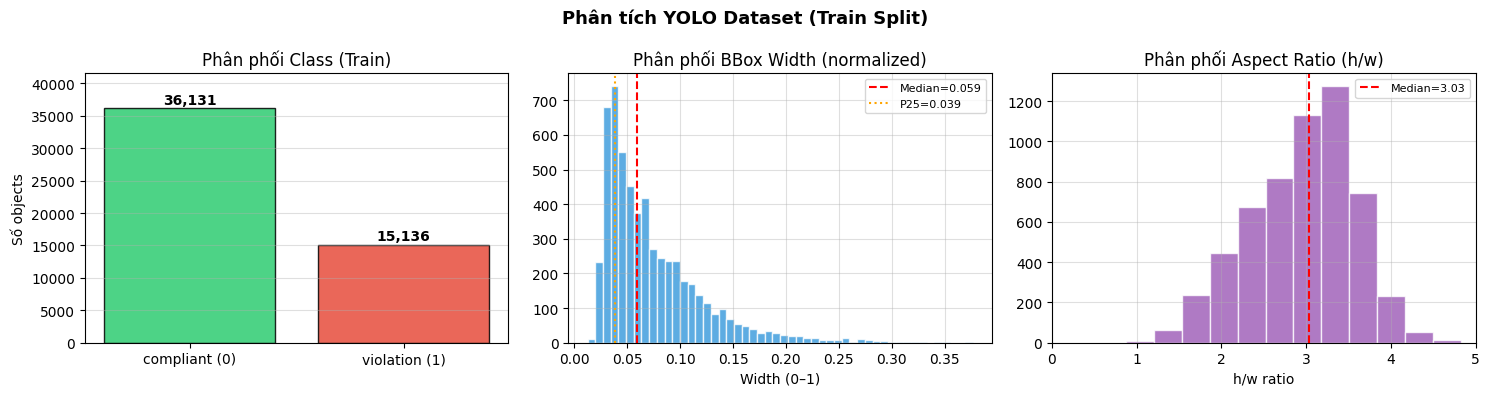


✓ Dataset analysis plot saved!


In [12]:
# ============================================================================
# VISUALIZE: Phân tích phân phối class và kích thước bbox
# ============================================================================

def analyze_bbox_distribution(dataset_dir: str, split: str = 'train', max_files: int = 2000):
    """
    Phân tích phân phối kích thước bounding box để chọn anchor size phù hợp.
    """
    lbl_dir = os.path.join(dataset_dir, split, 'labels')
    if not os.path.exists(lbl_dir):
        return None, None
    
    widths, heights, areas = [], [], []
    files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    files = random.sample(files, min(max_files, len(files)))
    
    for fname in files:
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, cx, cy, w, h = map(float, parts)
                    widths.append(w)
                    heights.append(h)
                    areas.append(w * h)
    
    return np.array(widths), np.array(heights), np.array(areas)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phân tích YOLO Dataset (Train Split)', fontsize=13, fontweight='bold')

# --- Plot 1: Class distribution ---
ax = axes[0]
train_stats = dataset_stats.get('train', {})
cls_counts  = train_stats.get('cls_counts', {0: 0, 1: 0})
bars = ax.bar(['compliant (0)', 'violation (1)'],
              [cls_counts[0], cls_counts[1]],
              color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='black')
for bar, val in zip(bars, [cls_counts[0], cls_counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Phân phối Class (Train)')
ax.set_ylabel('Số objects')
ax.set_ylim(0, max(cls_counts.values()) * 1.15)
ax.grid(axis='y', alpha=0.4)

# --- Plot 2: BBox width distribution ---
ax = axes[1]
widths, heights, areas = analyze_bbox_distribution(YOLO_DATASET_INPUT, 'train')
if widths is not None:
    ax.hist(widths, bins=50, color='#3498db', alpha=0.8, edgecolor='white')
    ax.axvline(np.median(widths), color='red', linestyle='--',
               label=f'Median={np.median(widths):.3f}')
    ax.axvline(np.percentile(widths, 25), color='orange', linestyle=':',
               label=f'P25={np.percentile(widths, 25):.3f}')
    ax.set_title('Phân phối BBox Width (normalized)')
    ax.set_xlabel('Width (0–1)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    print(f'\n📊 BBox Statistics (Train):')
    print(f'  Width  → Median: {np.median(widths):.4f} | P5: {np.percentile(widths,5):.4f} | P95: {np.percentile(widths,95):.4f}')
    print(f'  Height → Median: {np.median(heights):.4f} | P5: {np.percentile(heights,5):.4f} | P95: {np.percentile(heights,95):.4f}')
    print(f'  Area   → Median: {np.median(areas):.5f} | % small (<0.01): {(areas<0.01).mean()*100:.1f}%')
    small_pct = (areas < 0.005).mean() * 100
    if small_pct > 20:
        print(f'  ⚠️  {small_pct:.1f}% objects rất nhỏ (area < 0.005) → imgsz=1280 là lựa chọn đúng!')

# --- Plot 3: BBox aspect ratio ---
ax = axes[2]
if widths is not None and heights is not None:
    aspect = heights / np.clip(widths, 1e-6, None)  # h/w ratio
    ax.hist(aspect, bins=50, color='#9b59b6', alpha=0.8, edgecolor='white')
    ax.axvline(np.median(aspect), color='red', linestyle='--',
               label=f'Median={np.median(aspect):.2f}')
    ax.set_title('Phân phối Aspect Ratio (h/w)')
    ax.set_xlabel('h/w ratio')
    ax.set_xlim(0, 5)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'dataset_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()
print('\n✓ Dataset analysis plot saved!')


## Section 4: Xây dựng Custom Augmentation Pipeline

Ngoài augmentation mặc định của YOLO11, ta thêm preprocessing layer để handle:
- Frame từ video traffic có thể bị **motion blur** → thêm sharpening
- Video 10 FPS → nhiều frame tương tự nhau → mosaic+copy_paste tăng diversity

In [13]:
# ============================================================================
# AUGMENTATION: Tạo custom augmentation config cho YOLO11
# ============================================================================

# Ghi custom augmentation config ra file
# YOLO11 hỗ trợ override augmentation params qua training args
# Ta sẽ pass trực tiếp vào model.train()

AUG_PARAMS = dict(
    # ── Geometric augmentation ────────────────────────────────────────────
    degrees    = DEGREES,       # rotation: nhẹ (xe không nghiêng nhiều)
    translate  = TRANSLATE,     # dịch chuyển
    scale      = SCALE,         # scale: tăng diversity kích thước
    shear      = 2.0,           # shear nhẹ
    perspective= 0.0005,        # perspective rất nhẹ (camera cố định)
    flipud     = 0.0,           # KHÔNG flip dọc (xe không bay)
    fliplr     = FLIPLR,        # flip ngang: OK cho detection
    
    # ── Color augmentation ───────────────────────────────────────────────
    hsv_h      = HSV_H,         # hue
    hsv_s      = HSV_S,         # saturation (quan trọng cho outdoor lighting)
    hsv_v      = HSV_V,         # brightness
    
    # ── Mixing augmentation ──────────────────────────────────────────────
    mosaic     = MOSAIC,        # mosaic: combine 4 frames → simulates crowded scenes
    mixup      = MIXUP,         # mixup nhẹ
    copy_paste = COPY_PASTE,    # copy-paste: ghép xe máy vào frame khác
    
    # ── Erasing ──────────────────────────────────────────────────────────
    erasing    = 0.4,           # random erasing: simulates partial occlusion
    crop_fraction = 1.0,        # không crop
)

print('✓ Augmentation params đã cấu hình:')
for k, v in AUG_PARAMS.items():
    print(f'   {k:<15} = {v}')

✓ Augmentation params đã cấu hình:
   degrees         = 5.0
   translate       = 0.1
   scale           = 0.5
   shear           = 2.0
   perspective     = 0.0005
   flipud          = 0.0
   fliplr          = 0.5
   hsv_h           = 0.015
   hsv_s           = 0.7
   hsv_v           = 0.4
   mosaic          = 1.0
   mixup           = 0.05
   copy_paste      = 0.1
   erasing         = 0.4
   crop_fraction   = 1.0


## Section 5: Huấn luyện YOLO11n

### Kiến trúc YOLO11n
```
Input (640x640)
  │
  ├── Backbone: C3k2 × 4 stages (lightweight depthwise conv)
  │      + SPFF (Spatial Pyramid Fast Fusion)
  │      + C2PSA (Cross-Stage Partial + Self-Attention) ← MỚI
  │
  ├── Neck: PAN-FPN (Feature Pyramid)
  │      P3 (160×160) → detect small objects  ← quan trọng cho xe máy nhỏ
  │      P4 (80×80)   → detect medium objects
  │      P5 (40×40)   → detect large objects
  │
  └── Head: Decoupled (cls + reg branches)
         DFL (Distribution Focal Loss) regression
```

In [14]:
# ============================================================================
# TRAINING: Fine-tune YOLO11s trên YOLO Dataset từ Step 1
# ============================================================================

from ultralytics import YOLO
import gc
import time

# Giải phóng RAM trước khi train
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('=' * 70)
print(f'🚀 BẮT ĐẦU TRAINING: {MODEL_NAME}')
print(f'   Thời gian bắt đầu: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 70)

# Load YOLO11s (sẽ tự download pretrained weights từ Ultralytics)
model = YOLO(MODEL_NAME)
print(f'✓ Đã load model: {MODEL_NAME}')
print(f'  Số parameters: {sum(p.numel() for p in model.model.parameters()) / 1e6:.1f}M')

train_start = time.time()

# ── TRAINING ───────────────────────────────────────────────────────────────
results = model.train(
    # Data
    data    = PATCHED_YAML,
    imgsz   = IMG_SIZE,
    
    # Training schedule
    epochs   = 30,
    patience = PATIENCE,       # Early stopping
    batch    = BATCH_SIZE,
    workers  = 4,              # Kaggle T4 có 4 CPU cores
    
    # Optimizer
    optimizer = 'AdamW',
    lr0       = 0.001,         # Initial LR
    lrf       = 0.01,          # Final LR = lr0 * lrf
    momentum  = 0.937,
    weight_decay = 0.0005,
    
    # LR Scheduler
    cos_lr   = True,           # Cosine annealing (tốt hơn linear)
    warmup_epochs  = WARMUP_EP,
    warmup_momentum = 0.8,
    warmup_bias_lr  = 0.1,
    
    # Loss
    box   = 7.5,               # Box loss weight
    cls   = 0.5,               # Class loss weight
    dfl   = 1.5,               # DFL loss weight
    label_smoothing = LABEL_SMOOTHING,
    
    # Augmentation (unpack AUG_PARAMS)
    **AUG_PARAMS,
    
    # Output
    project  = os.path.join(OUTPUT_BASE, 'runs'),
    name     = 'helmet_yolo_v2',
    exist_ok = True,
    save     = True,
    save_period = 10,          # Lưu checkpoint mỗi 10 epochs
    
    # Hardware
    device = 0,                # GPU 0
    amp    = True,             # Mixed precision (giảm VRAM usage ~40%)
    
    # Misc
    seed     = SEED,
    verbose  = True,
    plots    = True,           # Lưu training curves
    val      = True,
    close_mosaic = 10,         # Tắt mosaic 10 epochs cuối để ổn định
)

train_duration = time.time() - train_start
print(f'\n✓ TRAINING HOÀN THÀNH! Tổng thời gian: {train_duration/60:.1f} phút')

🚀 BẮT ĐẦU TRAINING: yolo11n.pt
   Thời gian bắt đầu: 2026-04-06 10:11:16
✓ Đã load model: yolo11n.pt
  Số parameters: 2.6M
WARNING ⚠️ 'crop_fraction' is deprecated and will be removed in the future.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_v2.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0

## Section 6: Đánh giá Model trên Val & Test Set

In [15]:
# ============================================================================
# EVALUATION: Đánh giá best model trên val và test set
# ============================================================================

# Tìm best.pt
BEST_WEIGHTS = os.path.join(OUTPUT_BASE, 'runs', 'helmet_yolo_v2', 'weights', 'best.pt')
if not os.path.exists(BEST_WEIGHTS):
    # Thử path fallback
    BEST_WEIGHTS = os.path.join(OUTPUT_BASE, 'runs', 'helmet_yolo_v22', 'weights', 'best.pt')

print(f'📦 Loading best weights: {BEST_WEIGHTS}')
best_model = YOLO(BEST_WEIGHTS)

# ── VALIDATION SET ─────────────────────────────────────────────────────────
print('\n[1/2] Đánh giá trên Validation Set...')
val_metrics = best_model.val(
    data    = PATCHED_YAML,
    split   = 'val',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE * 2,  # Có thể dùng batch lớn hơn khi inference
    device  = 0,
    verbose = False,
    plots   = True,
    save_json = True,
    conf    = 0.25,
    iou     = 0.7,
)

# ── TEST SET ───────────────────────────────────────────────────────────────
print('\n[2/2] Đánh giá trên Test Set...')
test_metrics = best_model.val(
    data    = PATCHED_YAML,
    split   = 'test',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE * 2,
    device  = 0,
    verbose = False,
    plots   = True,
    save_json = True,
    conf    = 0.25,
    iou     = 0.7,
)

# ── IN KẾT QUẢ SO SÁNH ────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('📊 KẾT QUẢ SO SÁNH: YOLO11n (mới) vs YOLOv8s (cũ)')
print('=' * 70)

# Metrics cũ (hardcode từ Step 1 output)
OLD = {
    'val': {'mAP50': 0.8123, 'mAP50_95': 0.6953, 'precision': 0.8125, 'recall': 0.7482},
    'test': {'mAP50': 0.7823, 'mAP50_95': 0.6809, 'precision': 0.7542, 'recall': 0.7274},
}

NEW_val = {
    'mAP50':     round(float(val_metrics.box.map50), 4),
    'mAP50_95':  round(float(val_metrics.box.map),   4),
    'precision': round(float(val_metrics.box.mp),    4),
    'recall':    round(float(val_metrics.box.mr),    4),
}
NEW_test = {
    'mAP50':     round(float(test_metrics.box.map50), 4),
    'mAP50_95':  round(float(test_metrics.box.map),   4),
    'precision': round(float(test_metrics.box.mp),    4),
    'recall':    round(float(test_metrics.box.mr),    4),
}

def delta(new, old):
    d = new - old
    sign = '+' if d >= 0 else ''
    emoji = '✅' if d >= 0 else '❌'
    return f'{sign}{d:.4f} {emoji}'

print(f'  {"Metric":<15} {"YOLOv8s":>10} {"YOLO11s":>10} {"Delta":>12}')
print('-' * 55)
for k in ['mAP50', 'mAP50_95', 'precision', 'recall']:
    print(f'  VAL  {k:<10} {OLD["val"][k]:>10.4f} {NEW_val[k]:>10.4f} {delta(NEW_val[k], OLD["val"][k]):>12}')
print('-' * 55)
for k in ['mAP50', 'mAP50_95', 'precision', 'recall']:
    print(f'  TEST {k:<10} {OLD["test"][k]:>10.4f} {NEW_test[k]:>10.4f} {delta(NEW_test[k], OLD["test"][k]):>12}')
print('=' * 70)

📦 Loading best weights: /kaggle/working/runs/helmet_yolo_v2/weights/best.pt

[1/2] Đánh giá trên Validation Set...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 556.6±111.2 MB/s, size: 366.4 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 3003 images, 603 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3003/3003 1.0Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 4.1it/s 22.8s
                   all       3003       8553      0.779      0.745      0.797      0.693
Speed: 0.6ms preprocess, 2.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving /kaggle/working/runs/detect/val/predictions.json...
Results saved to /kaggle/working/runs/detect/val

[2/2] Đánh giá trên Test Set...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+

## Section 7: Benchmark Tốc Độ Inference

In [16]:
# ============================================================================
# SPEED BENCHMARK: Đo tốc độ inference để dự đoán performance khi dùng 
# cùng BoT-SORT tracker ở Step 3
# ============================================================================

import time

def benchmark_inference_speed(
    model,
    test_images_dir: str,
    imgsz: int = 1280,
    n_warmup: int = 5,
    n_runs: int = 50
) -> dict:
    """
    Đo tốc độ inference trung bình trên n_runs ảnh test.
    Bỏ qua n_warmup đầu để GPU warm up.
    """
    imgs = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg','.png'))]
    if not imgs:
        print('⚠️  Không tìm thấy ảnh test')
        return {}
    
    imgs = random.sample(imgs, min(n_warmup + n_runs, len(imgs)))
    
    # Warmup
    print(f'  Warming up ({n_warmup} frames)...')
    for fname in imgs[:n_warmup]:
        model.predict(os.path.join(test_images_dir, fname),
                      imgsz=imgsz, device=0, verbose=False)
    
    # Benchmark
    print(f'  Benchmarking ({n_runs} frames)...')
    latencies = []
    for fname in imgs[n_warmup:n_warmup+n_runs]:
        t0 = time.perf_counter()
        _ = model.predict(os.path.join(test_images_dir, fname),
                          imgsz=imgsz, device=0, verbose=False)
        latencies.append((time.perf_counter() - t0) * 1000)  # ms
    
    latencies = np.array(latencies)
    fps = 1000 / np.mean(latencies)
    
    results = {
        'mean_ms':   round(float(np.mean(latencies)),   2),
        'p50_ms':    round(float(np.median(latencies)), 2),
        'p95_ms':    round(float(np.percentile(latencies, 95)), 2),
        'p99_ms':    round(float(np.percentile(latencies, 99)), 2),
        'min_ms':    round(float(np.min(latencies)),    2),
        'max_ms':    round(float(np.max(latencies)),    2),
        'fps':       round(fps, 2),
        'imgsz':     imgsz,
    }
    return results

print('=' * 70)
print('⚡ BENCHMARK TỐC ĐỘ INFERENCE')
print('=' * 70)
print('  [imgsz=1280 — cấu hình training]')
test_imgs_dir = os.path.join(YOLO_DATASET_INPUT, 'test', 'images')

speed_1280 = benchmark_inference_speed(best_model, test_imgs_dir, imgsz=1280)

print(f'  [imgsz=640 — cấu hình inference nhanh (giảm 2x VRAM)]')
speed_640  = benchmark_inference_speed(best_model, test_imgs_dir, imgsz=640)

print('\n  Kết quả:')
print(f'  {"":<20} {"imgsz=1280":>12} {"imgsz=640":>12}')
print('-' * 48)
for k in ['mean_ms', 'p50_ms', 'p95_ms', 'fps']:
    unit = ' FPS' if k == 'fps' else ' ms'
    print(f'  {k:<20} {str(speed_1280.get(k,"-"))+unit:>12} {str(speed_640.get(k,"-"))+unit:>12}')

# Dataset is 10 FPS → cần YOLO chạy ít nhất 10 FPS để real-time
fps_ok_1280 = '✅ OK' if speed_1280.get('fps', 0) >= 10 else '⚠️  CHẬM'
fps_ok_640  = '✅ OK' if speed_640.get('fps', 0)  >= 10 else '⚠️  CHẬM'
print(f'\n  Dataset FPS = 10 → YOLO@1280: {fps_ok_1280} | YOLO@640: {fps_ok_640}')
print('=' * 70)

# Ghi vào biến để lưu vào summary
speed_results = {'imgsz_1280': speed_1280, 'imgsz_640': speed_640}


⚡ BENCHMARK TỐC ĐỘ INFERENCE
  [imgsz=1280 — cấu hình training]
  Warming up (5 frames)...
  Benchmarking (50 frames)...
  [imgsz=640 — cấu hình inference nhanh (giảm 2x VRAM)]
  Warming up (5 frames)...
  Benchmarking (50 frames)...

  Kết quả:
                         imgsz=1280    imgsz=640
------------------------------------------------
  mean_ms                  30.17 ms     21.91 ms
  p50_ms                   30.11 ms     21.65 ms
  p95_ms                   32.47 ms     25.02 ms
  fps                     33.14 FPS    45.64 FPS

  Dataset FPS = 10 → YOLO@1280: ✅ OK | YOLO@640: ✅ OK


## Section 8: Inference Demo — Visualize Detections

/tmp/ipykernel_23/1227854936.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1227854936.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1227854936.py:63: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(demo_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_23/1227854936.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(demo_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.p

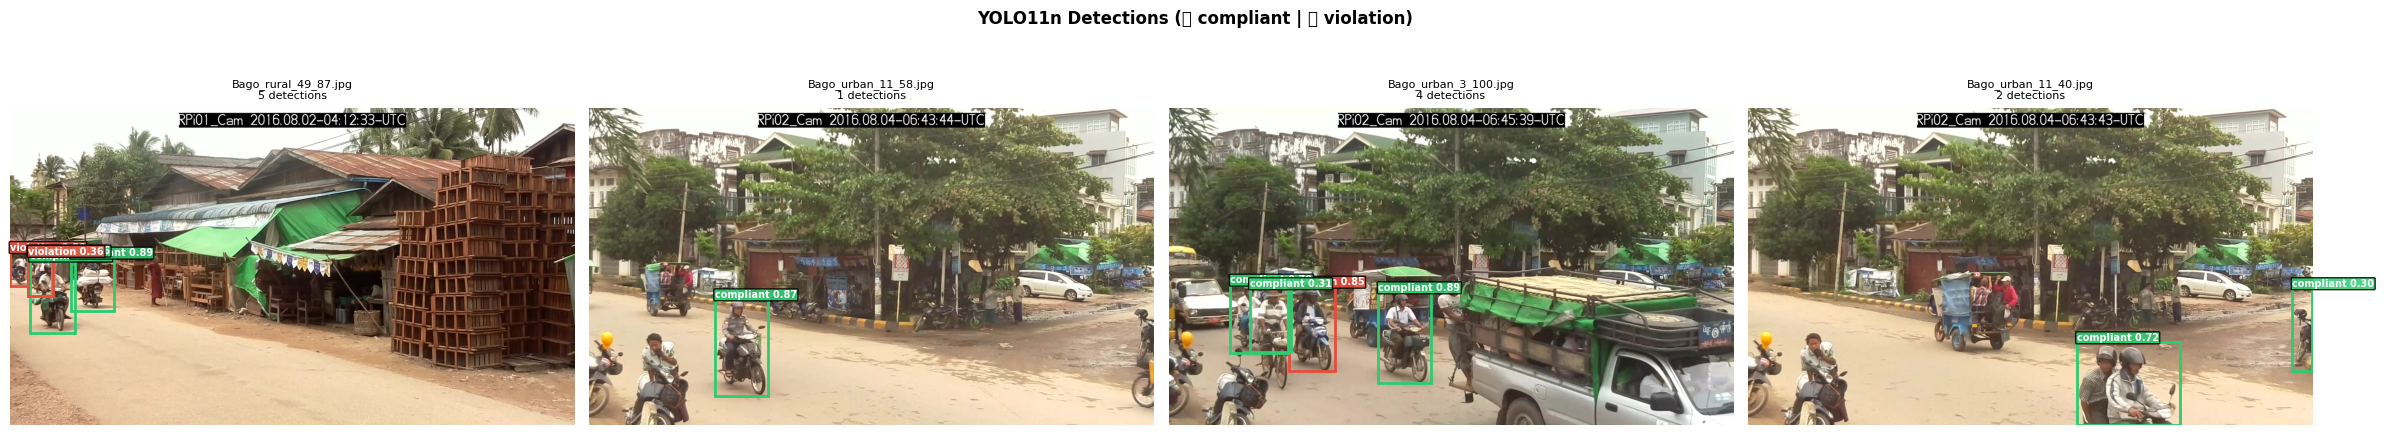


✓ Demo saved → /kaggle/working/inference_demo.png
✓ Inference demo complete!


In [17]:
# ============================================================================
# DEMO: Chạy inference trên ảnh test và visualize kết quả
# ============================================================================

def run_inference_demo(
    model,
    images_dir: str,
    n_samples: int = 4,
    conf: float = 0.25,
    iou: float = 0.7,
    imgsz: int = 1280,
):
    """
    Chạy YOLO inference và hiển thị kết quả với bounding box.
    Green = compliant, Red = violation.
    """
    CLASS_NAMES = {0: 'compliant', 1: 'violation'}
    COLORS      = {0: '#2ecc71', 1: '#e74c3c'}  # Green / Red
    
    frames = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
    if not frames:
        print(f'⚠️  Không tìm thấy .jpg frames trong {images_dir}')
        return
    
    sampled = random.sample(frames, min(n_samples, len(frames)))
    fig, axes = plt.subplots(1, len(sampled), figsize=(6 * len(sampled), 5))
    if len(sampled) == 1:
        axes = [axes]
    
    for ax, fname in zip(axes, sampled):
        img_path = os.path.join(images_dir, fname)
        preds = model.predict(
            source=img_path, conf=conf, iou=iou,
            imgsz=imgsz, device=0, verbose=False
        )[0]
        
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        
        for box in preds.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            cls   = int(box.cls[0])
            conf_ = float(box.conf[0])
            color = COLORS.get(cls, '#95a5a6')
            
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 5,
                    f"{CLASS_NAMES.get(cls,'?')} {conf_:.2f}",
                    color='white', fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor=color, alpha=0.85))
        
        n_det = len(preds.boxes)
        ax.set_title(f'{fname[:25]}\n{n_det} detections', fontsize=8)
        ax.axis('off')
    
    plt.suptitle('YOLO11n Detections (🟢 compliant | 🔴 violation)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    demo_path = os.path.join(OUTPUT_BASE, 'inference_demo.png')
    plt.savefig(demo_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✓ Demo saved → {demo_path}')


run_inference_demo(
    best_model,
    test_imgs_dir,
    n_samples=4,
    imgsz=1280,
)
print('✓ Inference demo complete!')

## Section 9: Tìm Optimal Confidence Threshold cho Step 3

Với BoT-SORT, ta cần chọn `conf` threshold tối ưu:
- **Quá thấp** → nhiều false positive → tracker loạn
- **Quá cao** → bỏ sót xe (đặc biệt xe nhỏ / bị che khuất) → tracker mất track


🎯 THRESHOLD SWEEP — Tìm conf tối ưu cho Step 3 (BoT-SORT)
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 494.3±106.7 MB/s, size: 330.1 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 3003 images, 603 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3003/3003 839.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 4.3it/s 21.9s
                   all       3003       8553      0.779      0.745      0.799      0.692
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 0.7ms postprocess per image
  conf=0.15 → mAP50=0.7991 | P=0.7786 | R=0.7447 | F1=0.7613
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 481.2±146.1 MB/s, size: 297.0 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 3003 images, 603 backgrounds, 0 corru

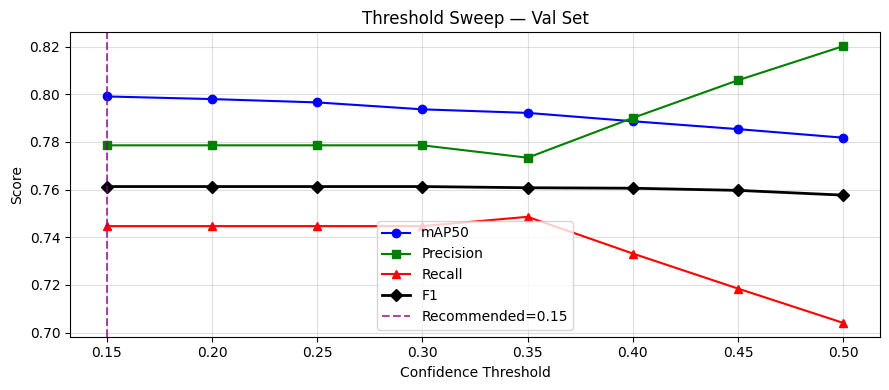

✓ Threshold sweep plot saved!


In [18]:
# ============================================================================
# THRESHOLD TUNING: Tìm confidence threshold tối ưu cho Step 3
# ============================================================================

print('=' * 70)
print('🎯 THRESHOLD SWEEP — Tìm conf tối ưu cho Step 3 (BoT-SORT)')
print('=' * 70)

conf_thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for conf_t in conf_thresholds:
    metrics = best_model.val(
        data    = PATCHED_YAML,
        split   = 'val',
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE * 2,
        device  = 0,
        verbose = False,
        conf    = conf_t,
        iou     = 0.7,
        plots   = False,
    )
    r = {
        'conf':      conf_t,
        'mAP50':     round(float(metrics.box.map50), 4),
        'precision': round(float(metrics.box.mp),    4),
        'recall':    round(float(metrics.box.mr),    4),
        'F1':        round(2 * float(metrics.box.mp) * float(metrics.box.mr) /
                           max(float(metrics.box.mp) + float(metrics.box.mr), 1e-6), 4),
    }
    threshold_results.append(r)
    print(f'  conf={conf_t:.2f} → mAP50={r["mAP50"]:.4f} | P={r["precision"]:.4f} | R={r["recall"]:.4f} | F1={r["F1"]:.4f}')

# Tìm conf có F1 cao nhất
best_thresh = max(threshold_results, key=lambda x: x['F1'])
print(f'\n🏆 Best conf threshold (F1-max): conf={best_thresh["conf"]} → F1={best_thresh["F1"]:.4f}')

# Cho BoT-SORT, ta muốn recall cao hơn precision (tránh bỏ sót xe)
# → chọn conf thấp hơn một chút so với F1-max
best_for_tracking = next(
    (r for r in reversed(threshold_results)
     if r['conf'] <= best_thresh['conf'] and r['recall'] >= 0.8),
    best_thresh
)
RECOMMENDED_CONF = best_for_tracking['conf']
print(f'📌 Recommended conf cho Step 3 (BoT-SORT): {RECOMMENDED_CONF}')
print(f'   (Ưu tiên Recall cao để tracker không mất track)')

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(9, 4))
confs = [r['conf'] for r in threshold_results]
ax.plot(confs, [r['mAP50']     for r in threshold_results], 'b-o', label='mAP50')
ax.plot(confs, [r['precision'] for r in threshold_results], 'g-s', label='Precision')
ax.plot(confs, [r['recall']    for r in threshold_results], 'r-^', label='Recall')
ax.plot(confs, [r['F1']        for r in threshold_results], 'k-D', label='F1', linewidth=2)
ax.axvline(RECOMMENDED_CONF, color='purple', linestyle='--', alpha=0.7,
           label=f'Recommended={RECOMMENDED_CONF}')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sweep — Val Set')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'threshold_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()
print('✓ Threshold sweep plot saved!')

## Section 10: Export & Lưu Kết Quả

In [19]:
# ============================================================================
# EXPORT: Copy best.pt và lưu summary JSON
# ============================================================================

# Copy best.pt → top-level để dễ dùng ở Step 3+
shutil.copy(BEST_WEIGHTS, FINAL_WEIGHTS)
print(f'✓ Best weights → {FINAL_WEIGHTS}')

# Build summary
summary = {
    'step':    '2_v2',
    'version': 'YOLO11s',
    'model':   MODEL_NAME,
    'training': {
        'imgsz':        IMG_SIZE,
        'epochs_max':   EPOCHS,
        'batch_size':   BATCH_SIZE,
        'optimizer':    'AdamW',
        'lr0':          0.001,
        'cos_lr':       True,
        'warmup_epochs': WARMUP_EP,
        'early_stopping_patience': PATIENCE,
        'label_smoothing': LABEL_SMOOTHING,
        'augmentation':  AUG_PARAMS,
        'training_time_min': round(train_duration / 60, 1),
    },
    'weights': {
        'best_pt': FINAL_WEIGHTS,
        'original': BEST_WEIGHTS,
    },
    'dataset': dataset_stats,
    'val_metrics': NEW_val,
    'test_metrics': NEW_test,
    'old_val_metrics': OLD['val'],
    'old_test_metrics': OLD['test'],
    'improvement': {
        'val_mAP50_delta':  round(NEW_val['mAP50'] - OLD['val']['mAP50'], 4),
        'test_mAP50_delta': round(NEW_test['mAP50'] - OLD['test']['mAP50'], 4),
    },
    'inference_speed': speed_results,
    'threshold_sweep': threshold_results,
    'recommended_conf_for_step3': RECOMMENDED_CONF,
    'classes': {'0': 'compliant', '1': 'violation'},
}

with open(SUMMARY_PATH, 'w') as f:
    json.dump(summary, f, indent=4)

print(f'✓ Summary JSON → {SUMMARY_PATH}')

# ── IN TỔNG KẾT CUỐI ───────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('✅ STEP 2 (v2) HOÀN THÀNH — Tổng kết')
print('=' * 70)
print(f'  Model        : {MODEL_NAME} (YOLO11s)')
print(f'  Best weights : {FINAL_WEIGHTS}')
print(f'  Training time: {round(train_duration/60, 1)} phút')
print()
print('  VAL metrics:')
for k, v in NEW_val.items():
    old_v = OLD['val'][k]
    d = v - old_v
    emoji = '✅' if d >= 0 else '❌'
    print(f'    {k:<15}: {v:.4f}  (cũ: {old_v:.4f}, Δ={d:+.4f} {emoji})')
print()
print('  TEST metrics:')
for k, v in NEW_test.items():
    old_v = OLD['test'][k]
    d = v - old_v
    emoji = '✅' if d >= 0 else '❌'
    print(f'    {k:<15}: {v:.4f}  (cũ: {old_v:.4f}, Δ={d:+.4f} {emoji})')
print()
print(f'  Recommended conf cho Step 3: {RECOMMENDED_CONF}')
print()
print('  Bước tiếp theo:')
print(f'    1. Lưu {FINAL_WEIGHTS} thành Kaggle Dataset output')
print(f'    2. Add dataset này vào Step 3 (BoT-SORT) notebook')
print(f'    3. Dùng conf={RECOMMENDED_CONF} khi gọi model.track() ở Step 3')
print('=' * 70)

✓ Best weights → /kaggle/working/yolo_best_v2.pt
✓ Summary JSON → /kaggle/working/step2_v2_train_summary.json

✅ STEP 2 (v2) HOÀN THÀNH — Tổng kết
  Model        : yolo11n.pt (YOLO11s)
  Best weights : /kaggle/working/yolo_best_v2.pt
  Training time: 153.0 phút

  VAL metrics:
    mAP50          : 0.7966  (cũ: 0.8123, Δ=-0.0157 ❌)
    mAP50_95       : 0.6935  (cũ: 0.6953, Δ=-0.0018 ❌)
    precision      : 0.7786  (cũ: 0.8125, Δ=-0.0339 ❌)
    recall         : 0.7447  (cũ: 0.7482, Δ=-0.0035 ❌)

  TEST metrics:
    mAP50          : 0.7589  (cũ: 0.7823, Δ=-0.0234 ❌)
    mAP50_95       : 0.6636  (cũ: 0.6809, Δ=-0.0173 ❌)
    precision      : 0.7483  (cũ: 0.7542, Δ=-0.0059 ❌)
    recall         : 0.7063  (cũ: 0.7274, Δ=-0.0211 ❌)

  Recommended conf cho Step 3: 0.15

  Bước tiếp theo:
    1. Lưu /kaggle/working/yolo_best_v2.pt thành Kaggle Dataset output
    2. Add dataset này vào Step 3 (BoT-SORT) notebook
    3. Dùng conf=0.15 khi gọi model.track() ở Step 3
